In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from utils.kf_utils import load_custom_dataset
from utils.run_estimation import run_state_estimation
from utils.plot_data import *

sim_num = 3
dataset_num = 1
data = load_custom_dataset(
    dataset_path=Path.cwd().parent / f"custom_datasets/quad_mass_dataset_run{dataset_num}.npz", 
    sim_num=sim_num)

Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run1.npz.


## Estimating pos, lin vel, ang vel and contact force - with payload on robot

With added payload on the robot's base.

In [3]:
start = 0
end = len(data["dt"])

result = run_state_estimation(dt=data["dt"][0],
                              base_orient=data["base_orient"],
                              base_ang_vel=data["base_ang_vel"],
                              joint_pos=data["joint_pos"],
                              joint_vel=data["joint_vel"],
                              joint_acc=data["joint_acc"],
                              joint_torque=data["joint_torque"],
                              contact_states=data["contact_states"],
                              Q=[0.0001, 0.0001, 0.0001, 0.001],
                              R=[0.1, 0.1, 0.0001, 0.01],
                              est_mode=4)

/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Running state estimation:  24%|██▍       | 121/500 [00:00<00:00, 1205.29it/s]

Estimating contact forces with joint torque
Estimating base accelaration with dynamics


Running state estimation: 100%|██████████| 500/500 [00:00<00:00, 1208.96it/s]


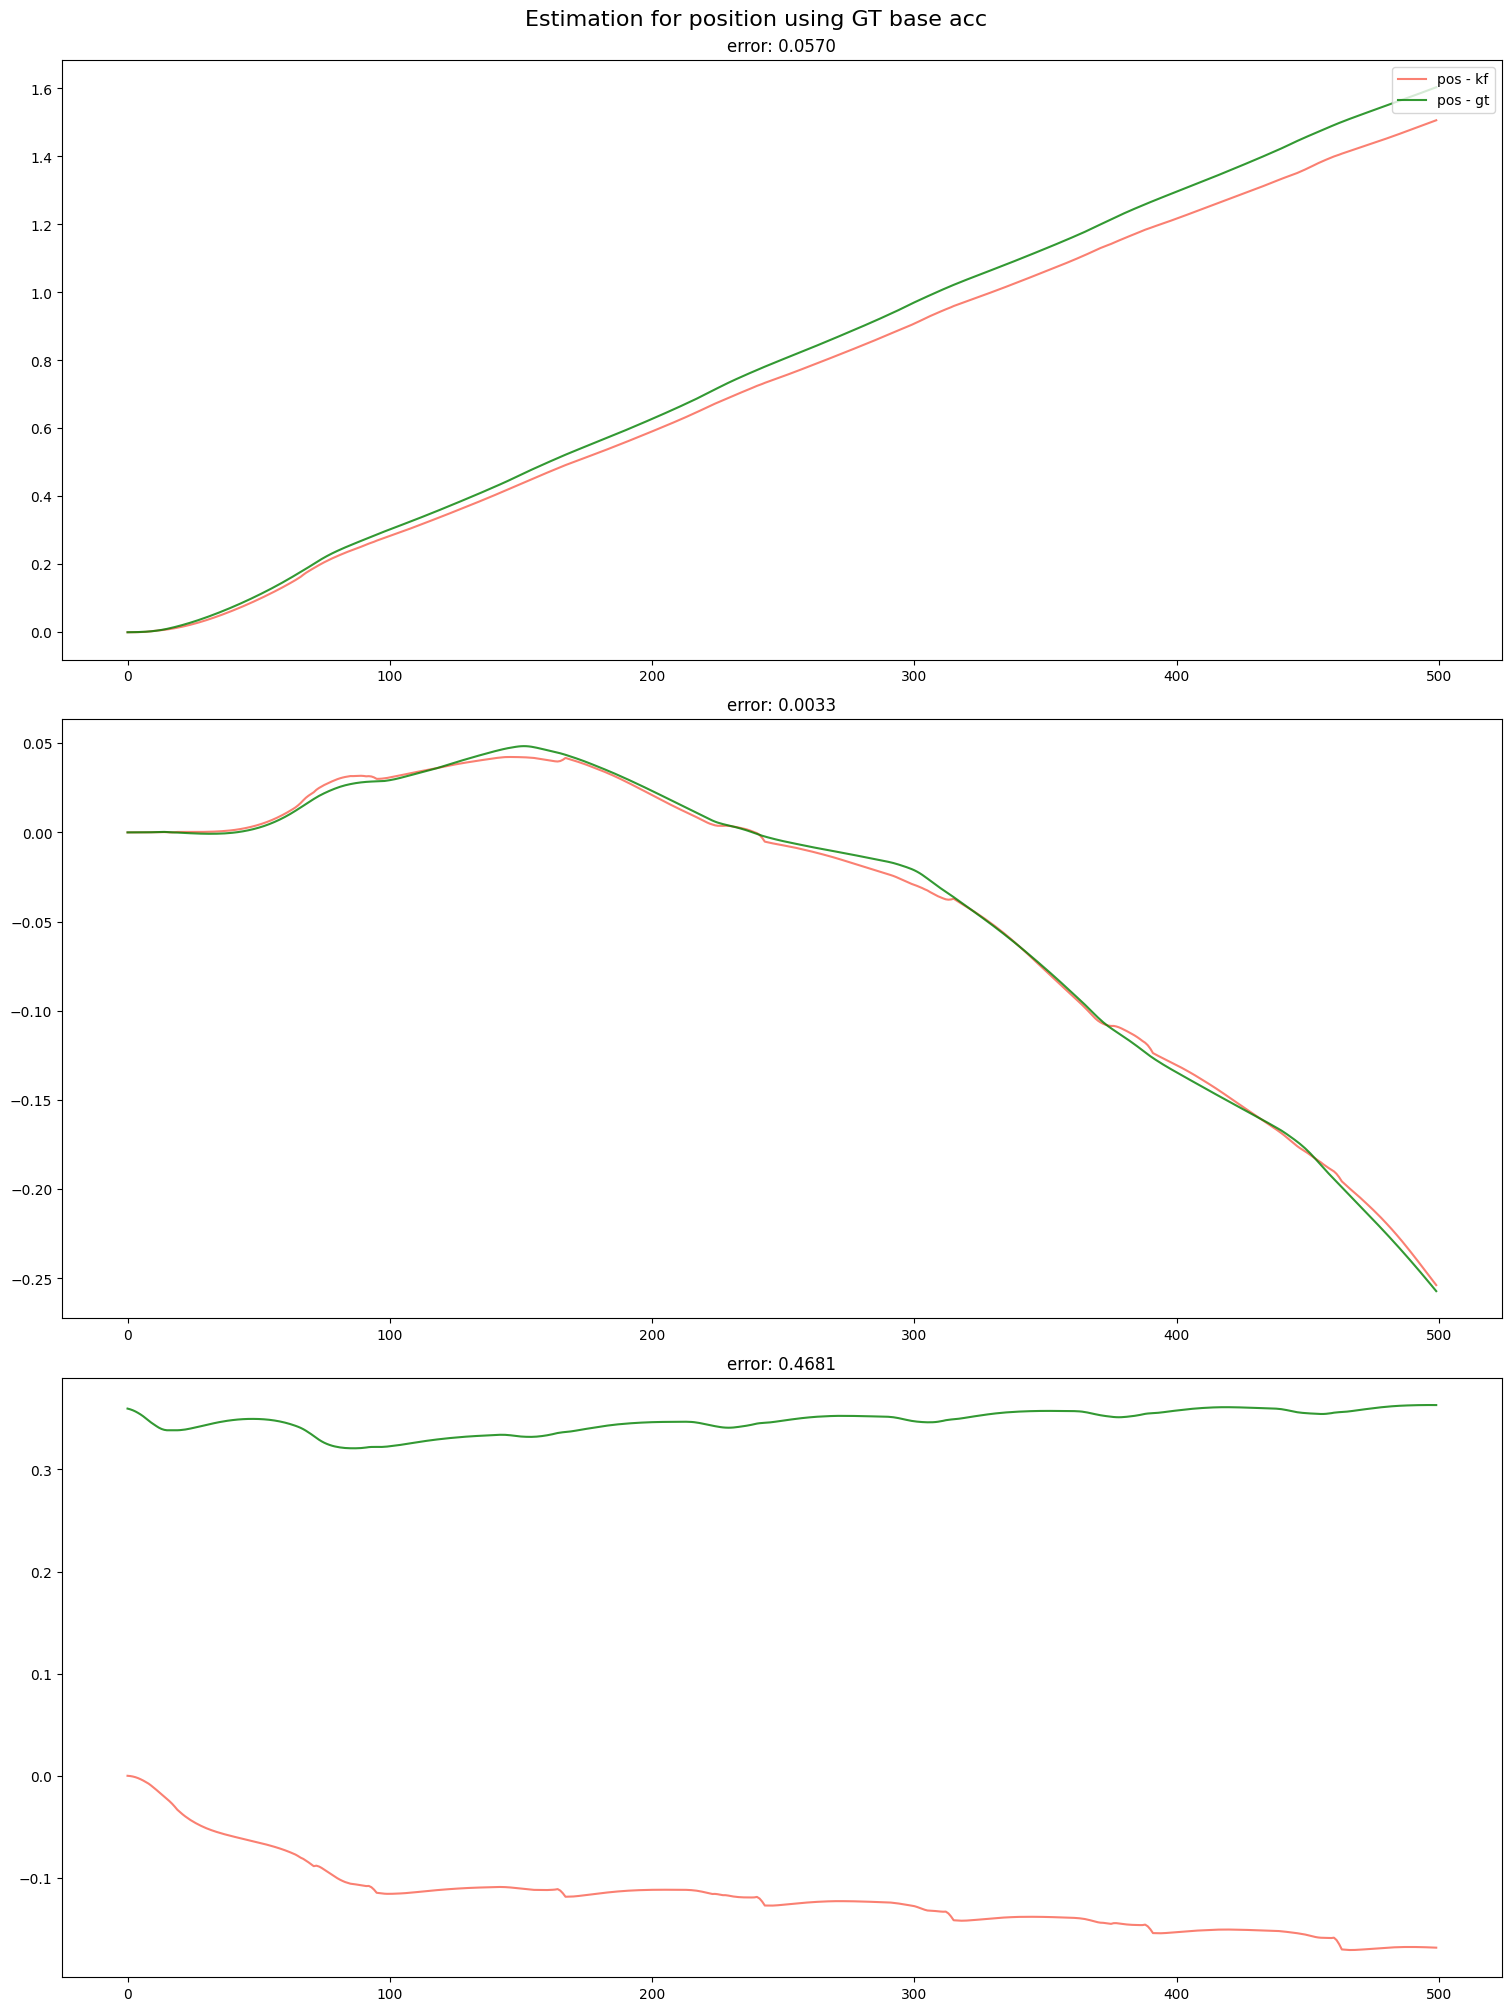

In [6]:
estimation_plot(gt_value=data["base_pos"],
                est_value=result["pos_update"],
                label="pos",
                title="Estimation for position using GT base acc")

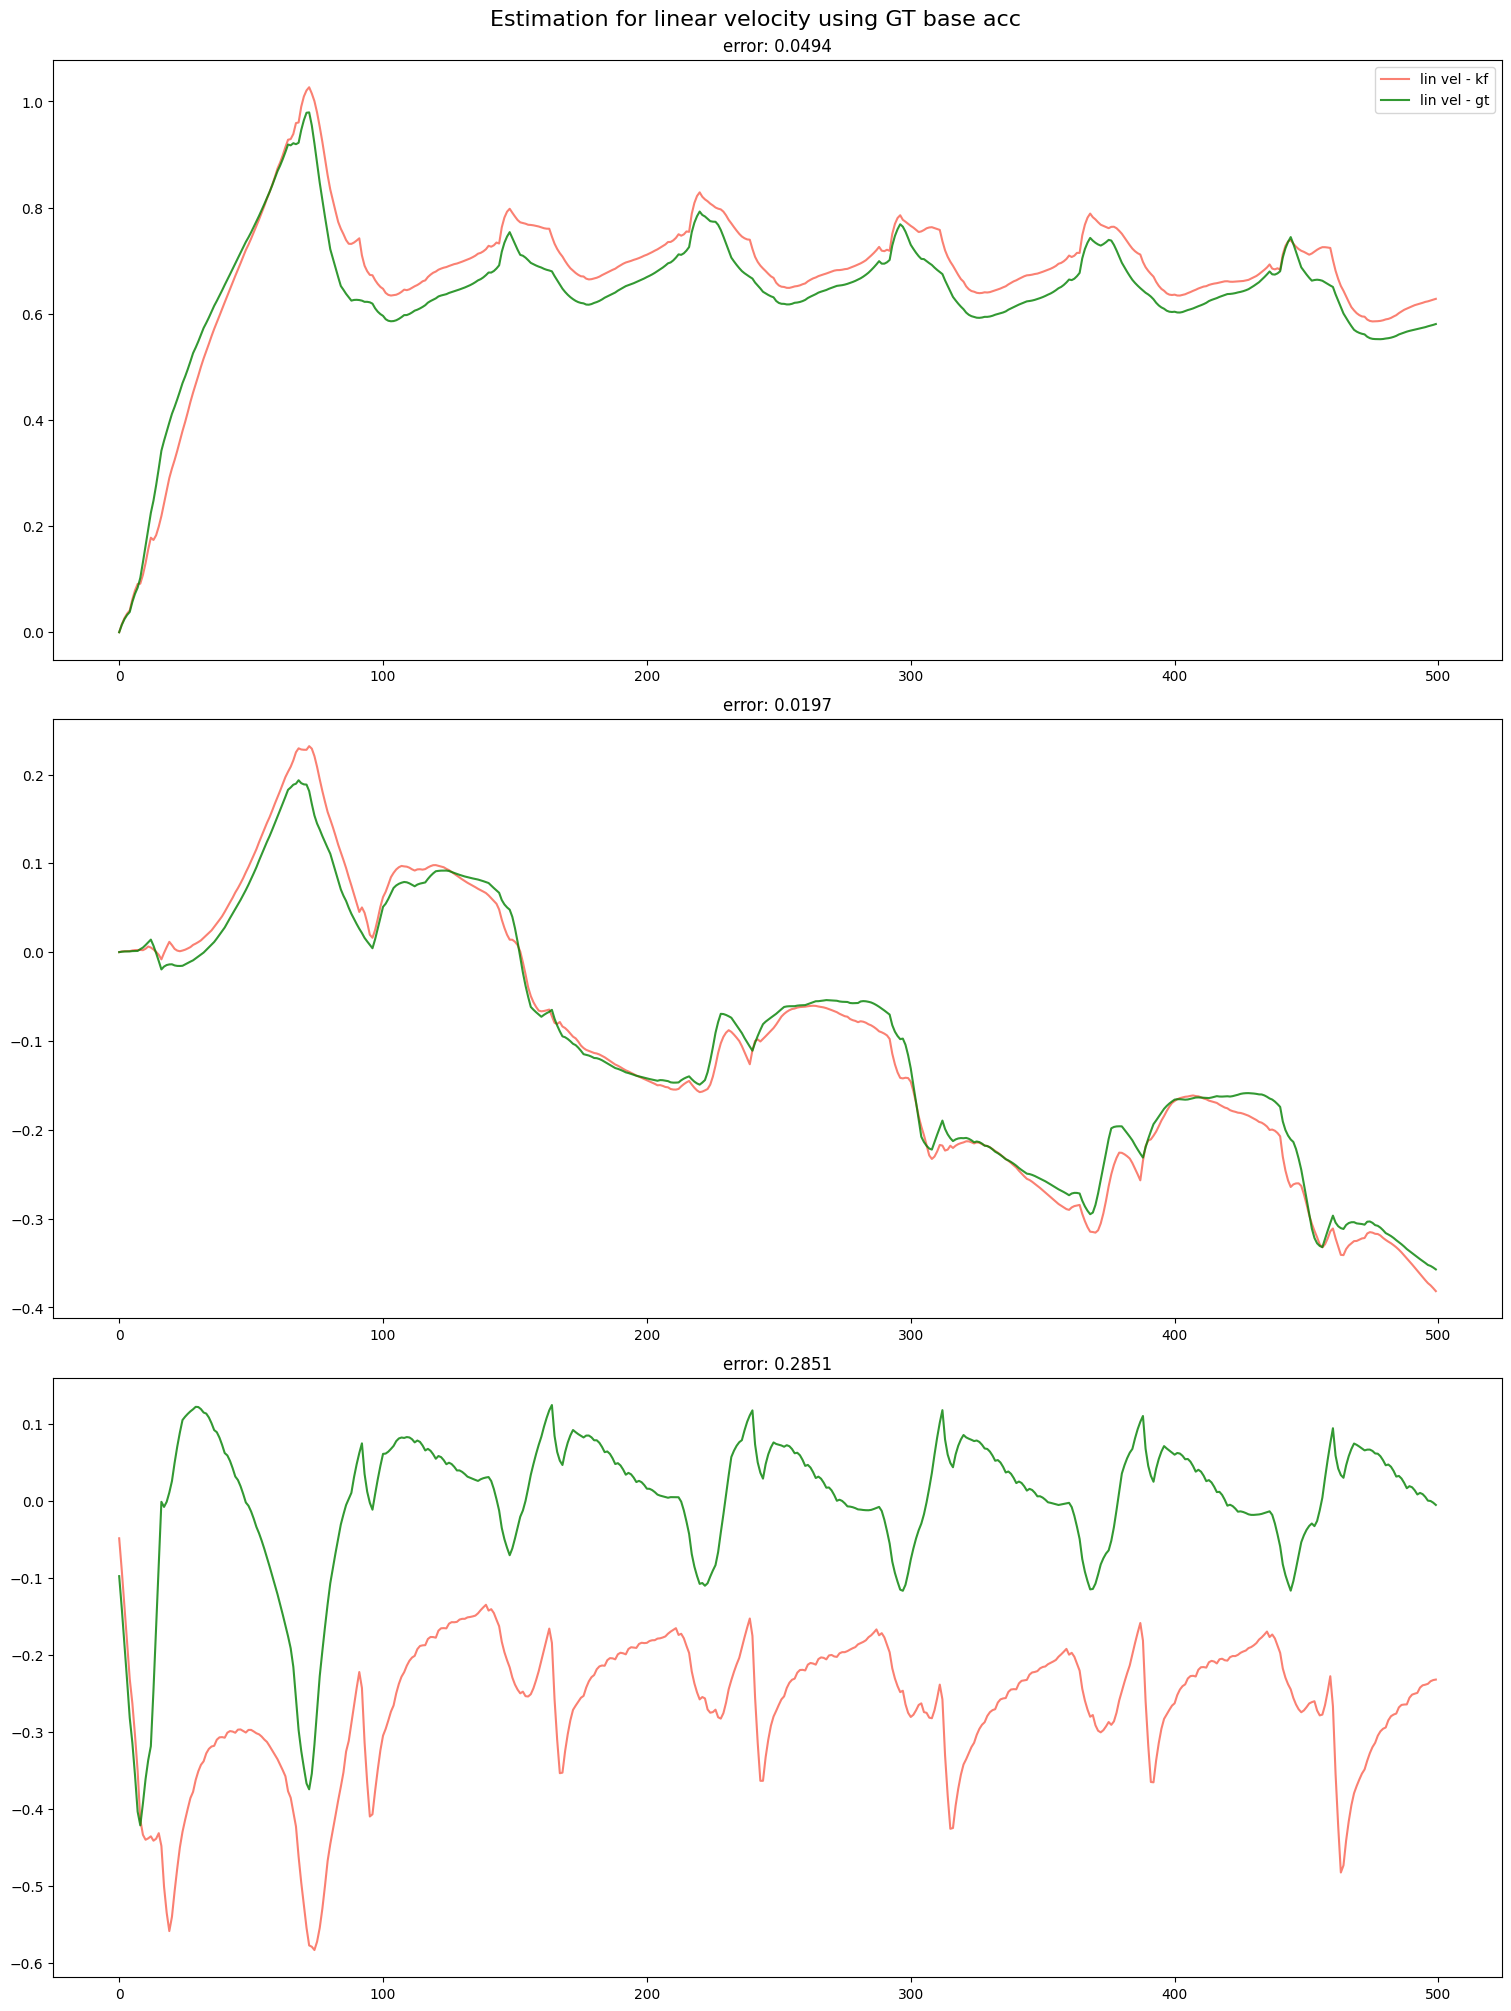

In [7]:
estimation_plot(gt_value=data["base_vel"],
                est_value=result["vel_update"],
                label="lin vel",
                title="Estimation for linear velocity using GT base acc")

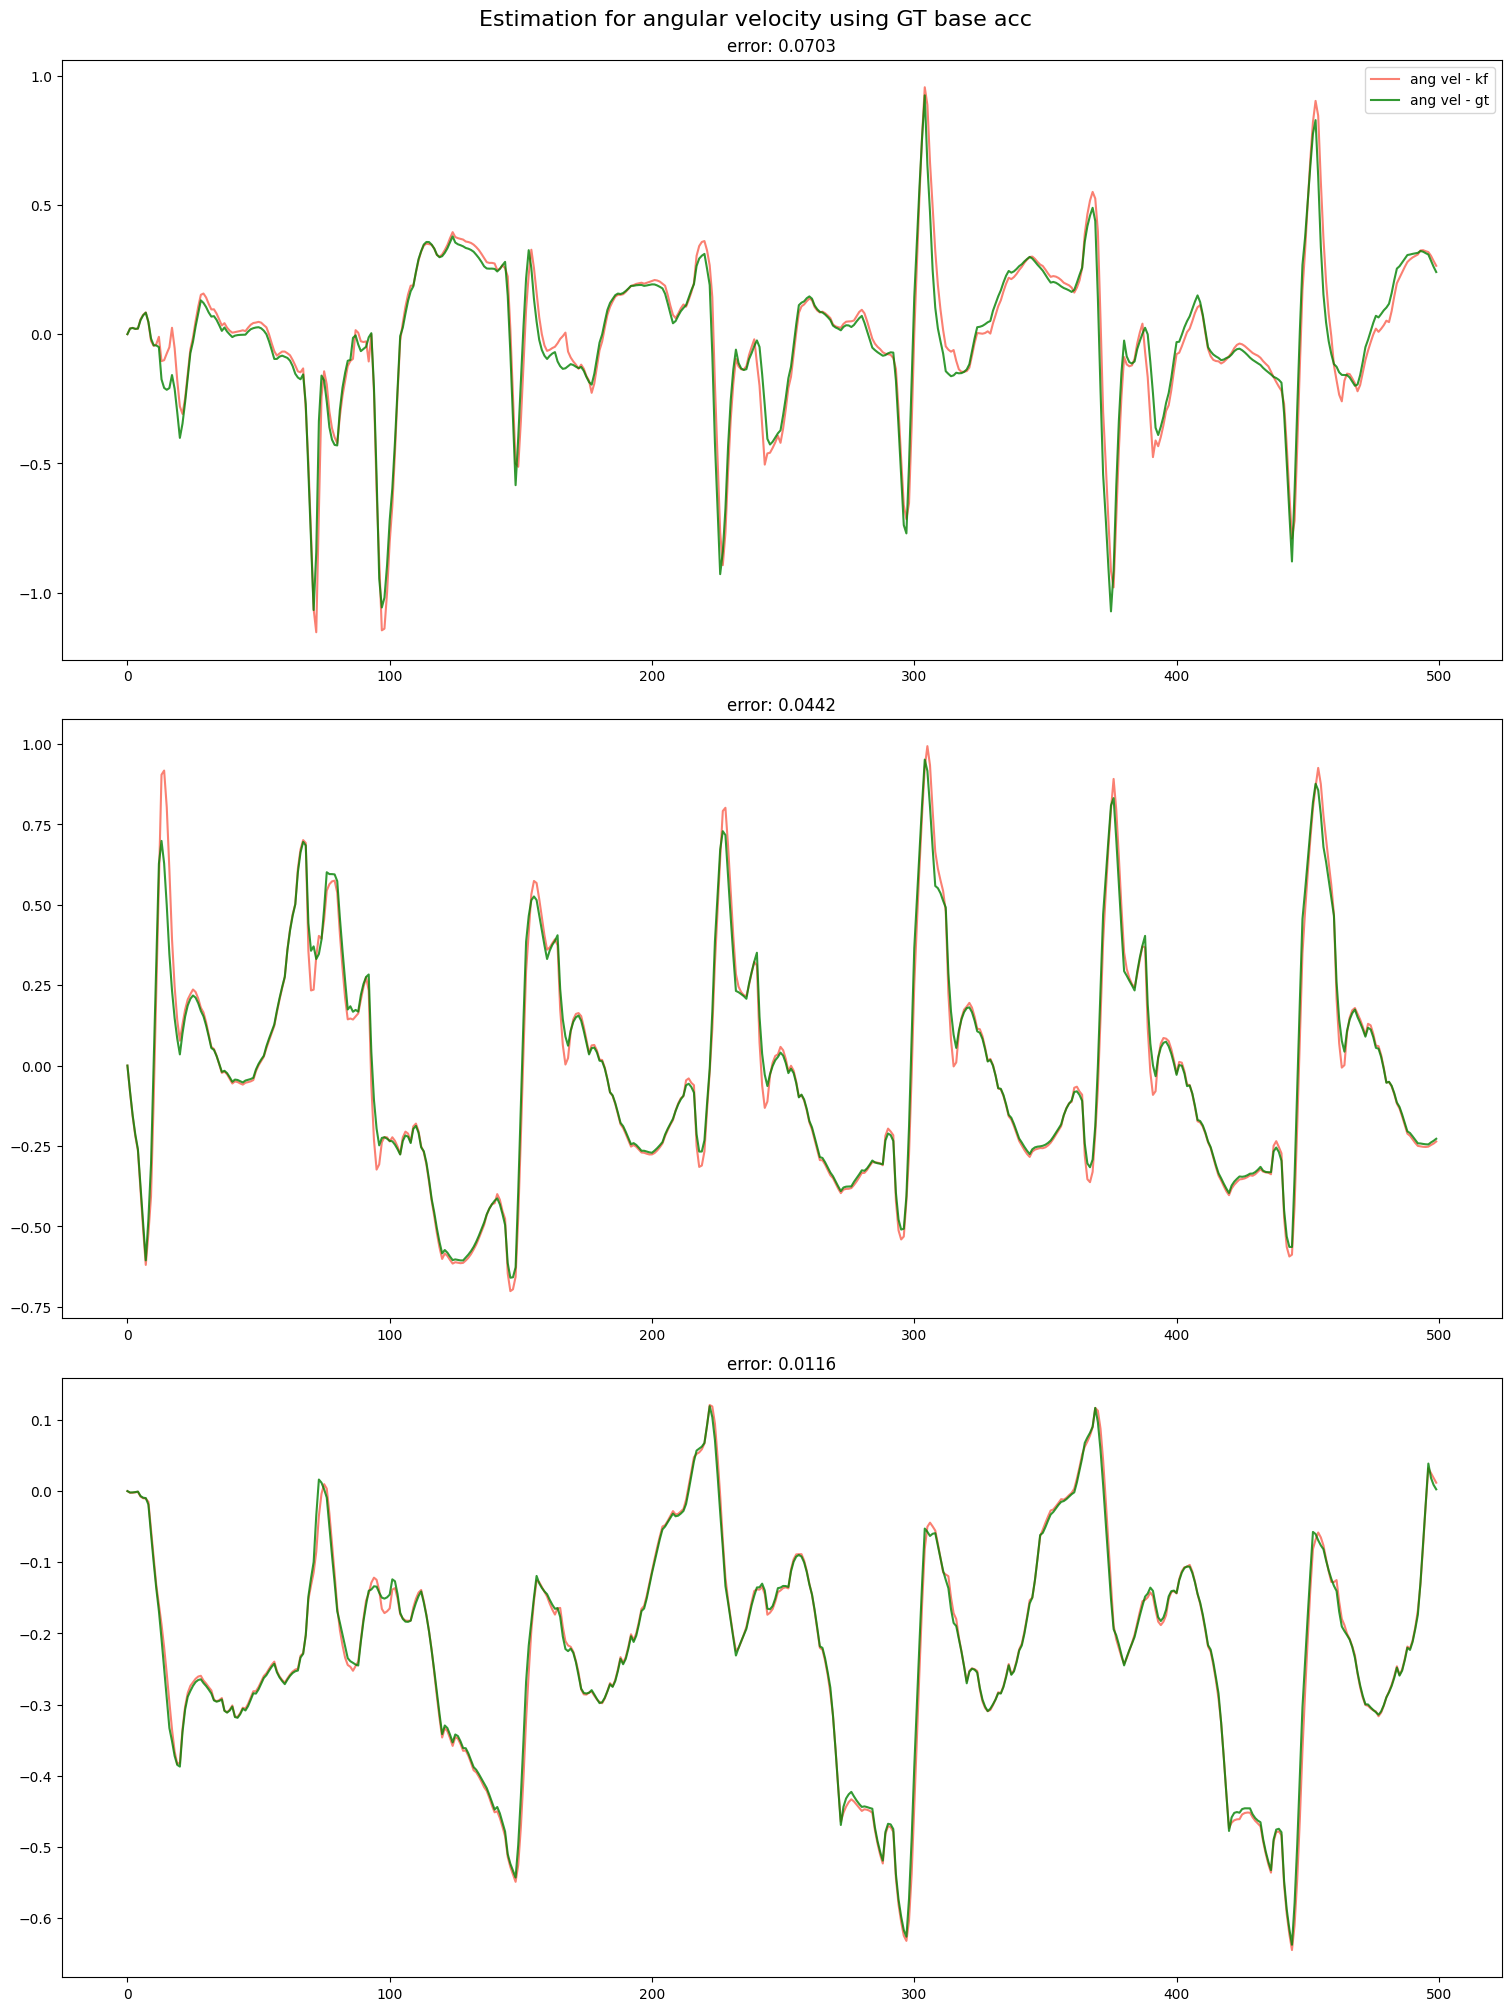

In [8]:
estimation_plot(gt_value=data["base_ang_vel"],
                est_value=result["ang_vel_update"],
                label="ang vel",
                title="Estimation for angular velocity using GT base acc")

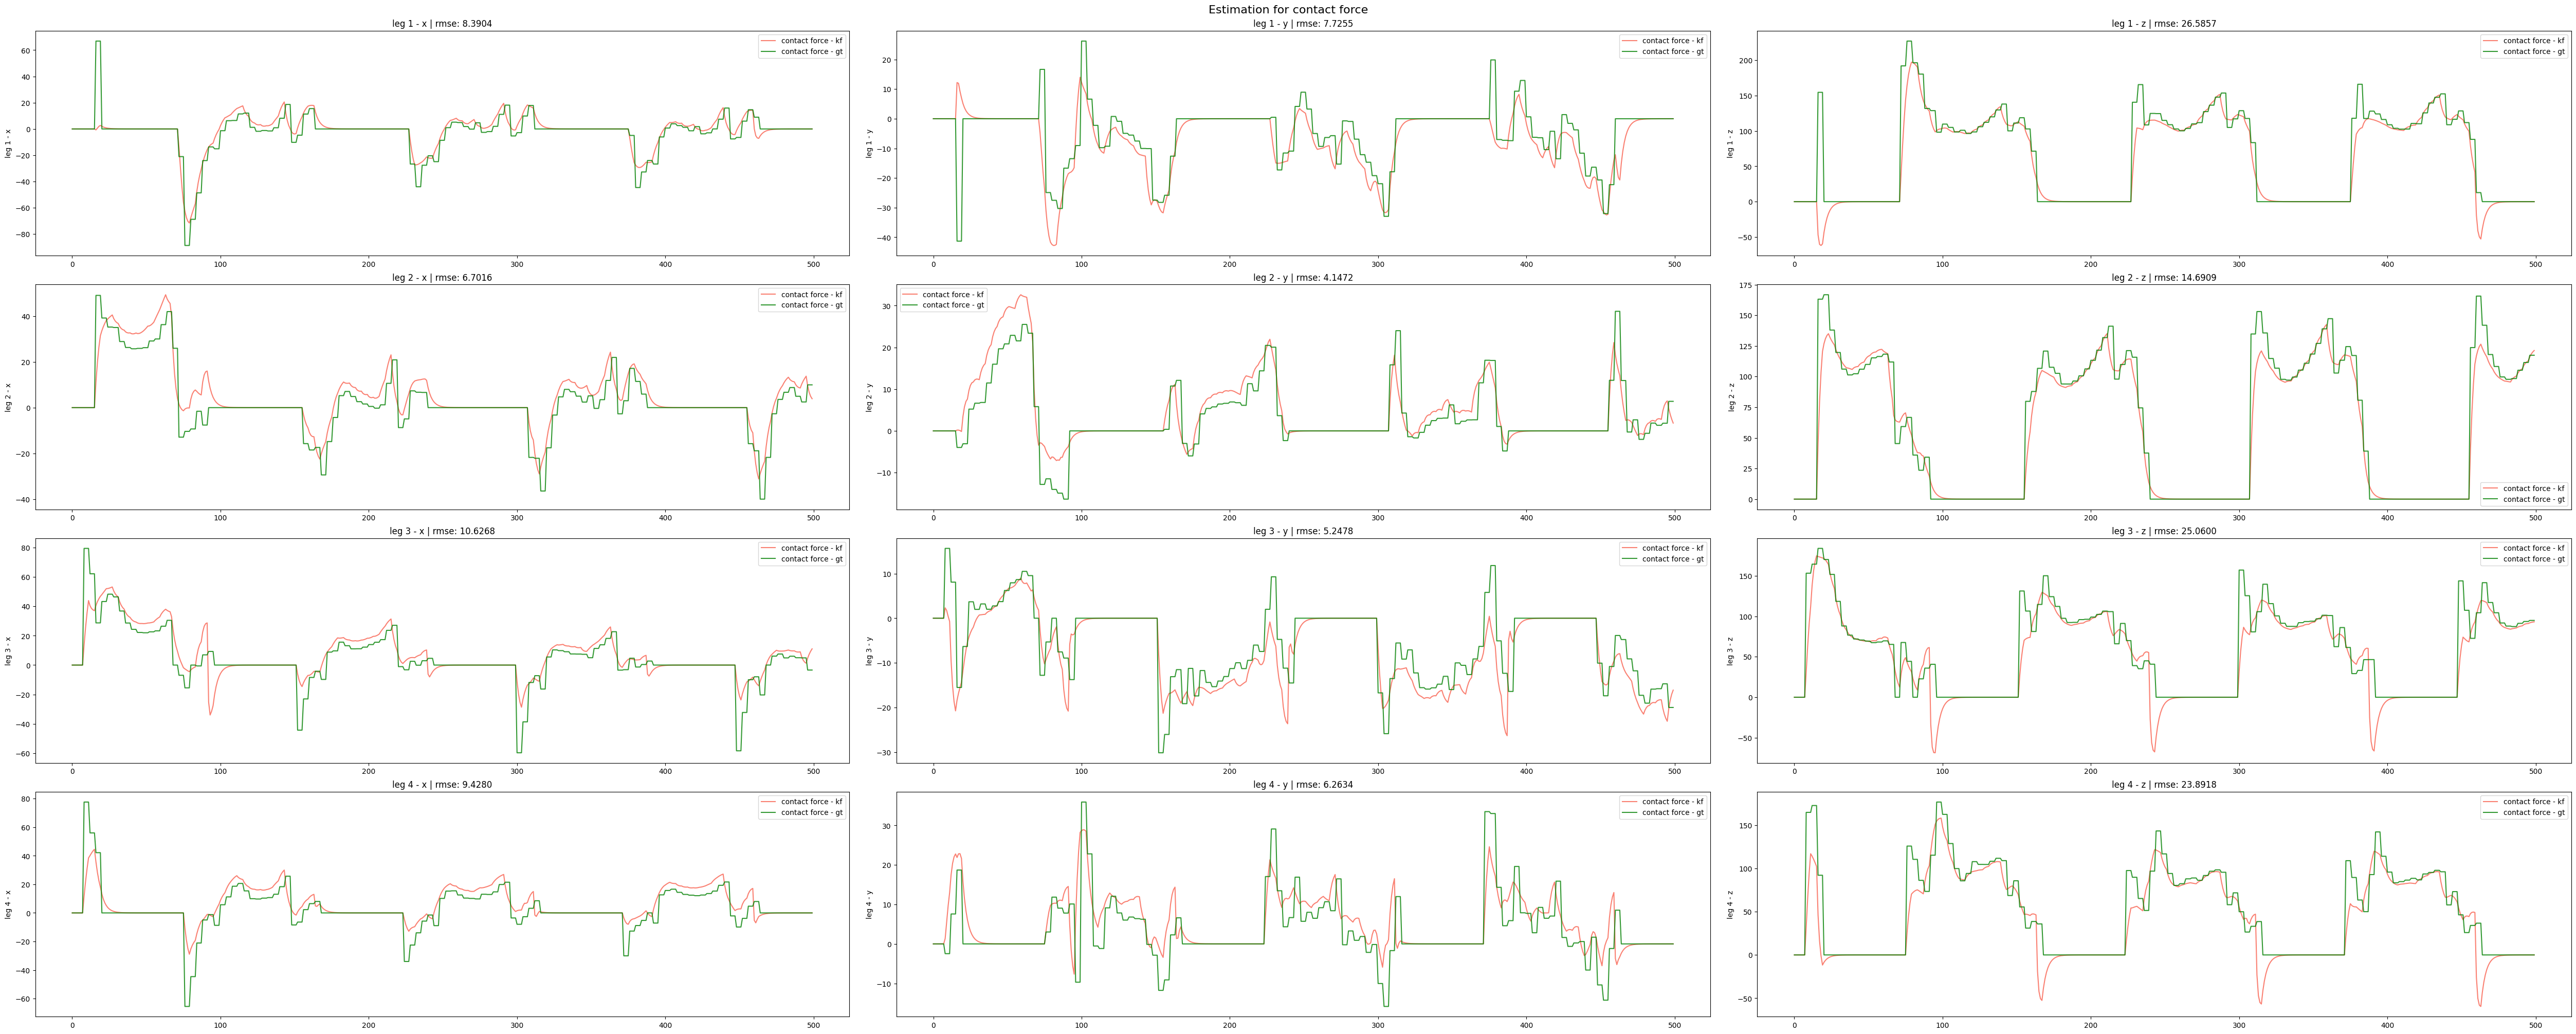

In [11]:
force_estimation_plot(gt_value=data["contact_forces"],
                      est_value=result["c_force_update"],
                      label="contact force",
                      start=0,
                      end=500,
                      title="Estimation for contact force")